# `local_thickness_bf`
Brute-force local thickness: inserts a sphere at every void voxel without trying to skip work. This is the slowest variant but serves as the reference implementation against which the others are validated.

See the `local_thickness` notebook for a detailed walk-through of the shared concepts; this page focuses on the variant-specific arguments. The wrapper `ps.filters.local_thickness` dispatches to this function when its `method` argument selects this variant.

In [1]:
import matplotlib.pyplot as plt

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.filters.local_thickness_bf)

<Signature (im, dt=None, mask=None, smooth=True)>

## `im`
A boolean image with `True` indicating the void phase. Use small images: this method is O(N) in the number of voxels and *slow*.

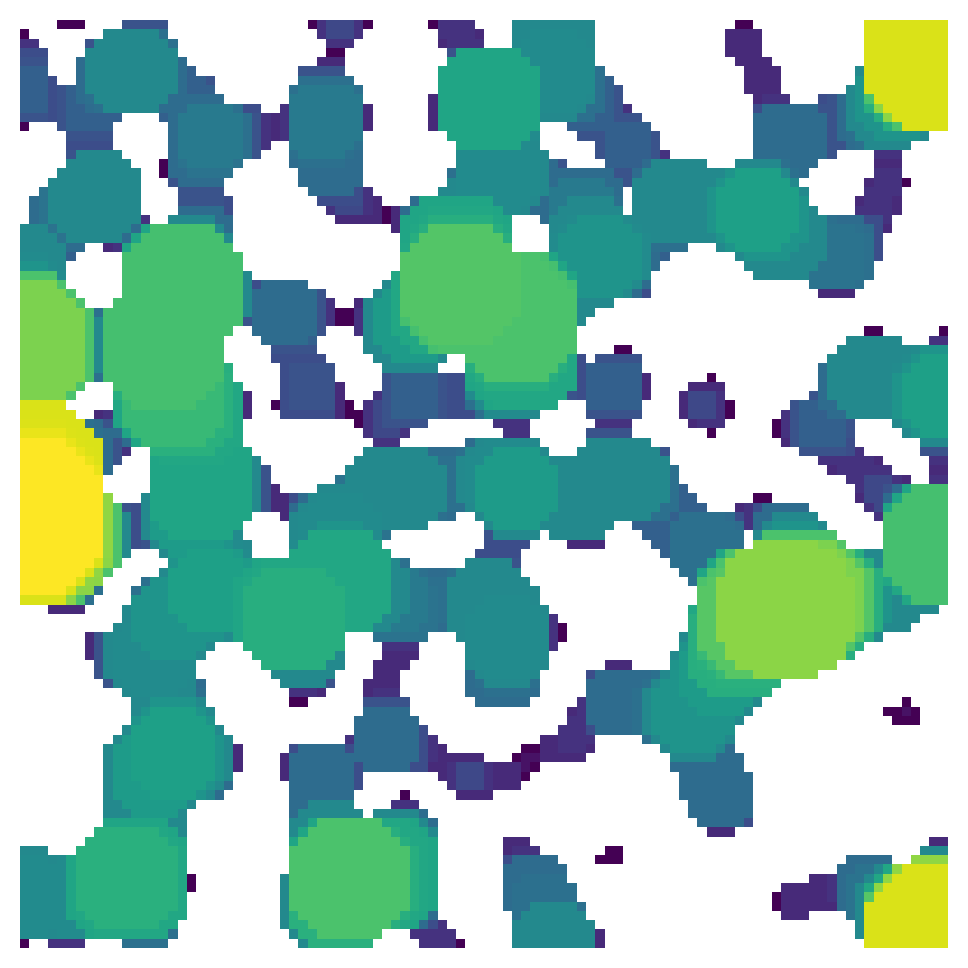

In [3]:
im = ps.generators.blobs(shape=[100, 100], porosity=0.6, seed=0)
lt = ps.filters.local_thickness_bf(im=im)

fig, ax = plt.subplots(figsize=[5, 5])
ax.imshow(lt / im, origin='lower', interpolation='none')
ax.axis(False);

## `dt`
Pre-computed distance transform of the void phase. Saves a small amount of time.

In [4]:
from porespy.tools import get_edt

dt = get_edt()(im)
lt = ps.filters.local_thickness_bf(im=im, dt=dt)

## `mask`
Restricts insertion sites to a subset of the void. Useful for spot-checking the local thickness in a region of interest.

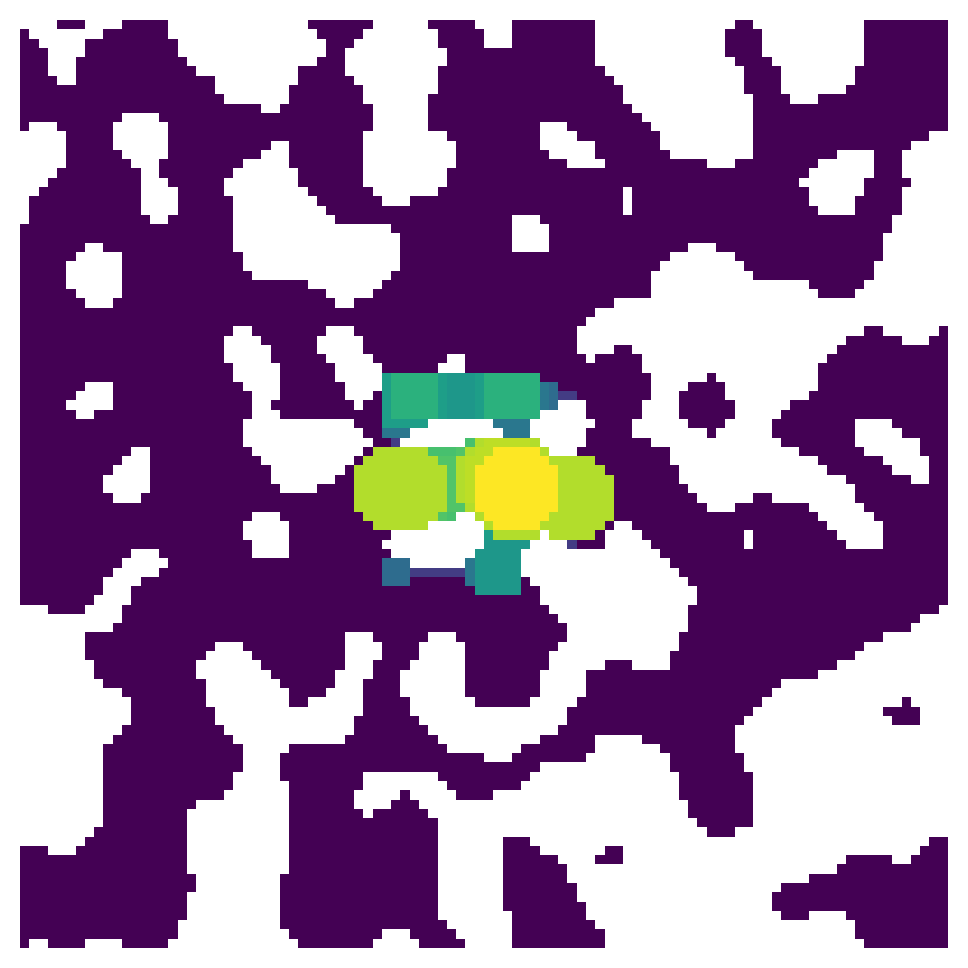

In [5]:
import numpy as np

mask = np.zeros_like(im)
mask[40:60, 40:60] = True
lt = ps.filters.local_thickness_bf(im=im, mask=mask & im)

fig, ax = plt.subplots(figsize=[5, 5])
ax.imshow(lt / im, origin='lower', interpolation='none')
ax.axis(False);

## `smooth`
When `True` (default) single-voxel protrusions are removed from the inserted spheres.

In [6]:
lt_smooth = ps.filters.local_thickness_bf(im=im, smooth=True)
lt_rough = ps.filters.local_thickness_bf(im=im, smooth=False)